✅ Загружено: 1000 компаний. Колонки: ['inn', 'fixed_assets', 'current_assets', 'equity', 'long_debt', 'short_debt', 'total_assets', 'total_liabilities', 'revenue', 'gross_profit', 'net_profit', 'cash_flow_op', 'money_in', 'money_out', 'year']

📊 Описательная статистика:
               inn  fixed_assets  current_assets        equity     long_debt    short_debt  total_assets  total_liabilities       revenue   gross_profit    net_profit   cash_flow_op      money_in     money_out    year
count         1000  2.860000e+02    7.050000e+02  6.760000e+02  3.120000e+02  6.130000e+02  7.610000e+02       7.610000e+02  5.500000e+02     559.000000  6.100000e+02      52.000000  5.000000e+01  5.100000e+01  1000.0
unique        1000           NaN             NaN           NaN           NaN           NaN           NaN                NaN           NaN            NaN           NaN            NaN           NaN           NaN     NaN
top     3459084723           NaN             NaN           NaN           Na

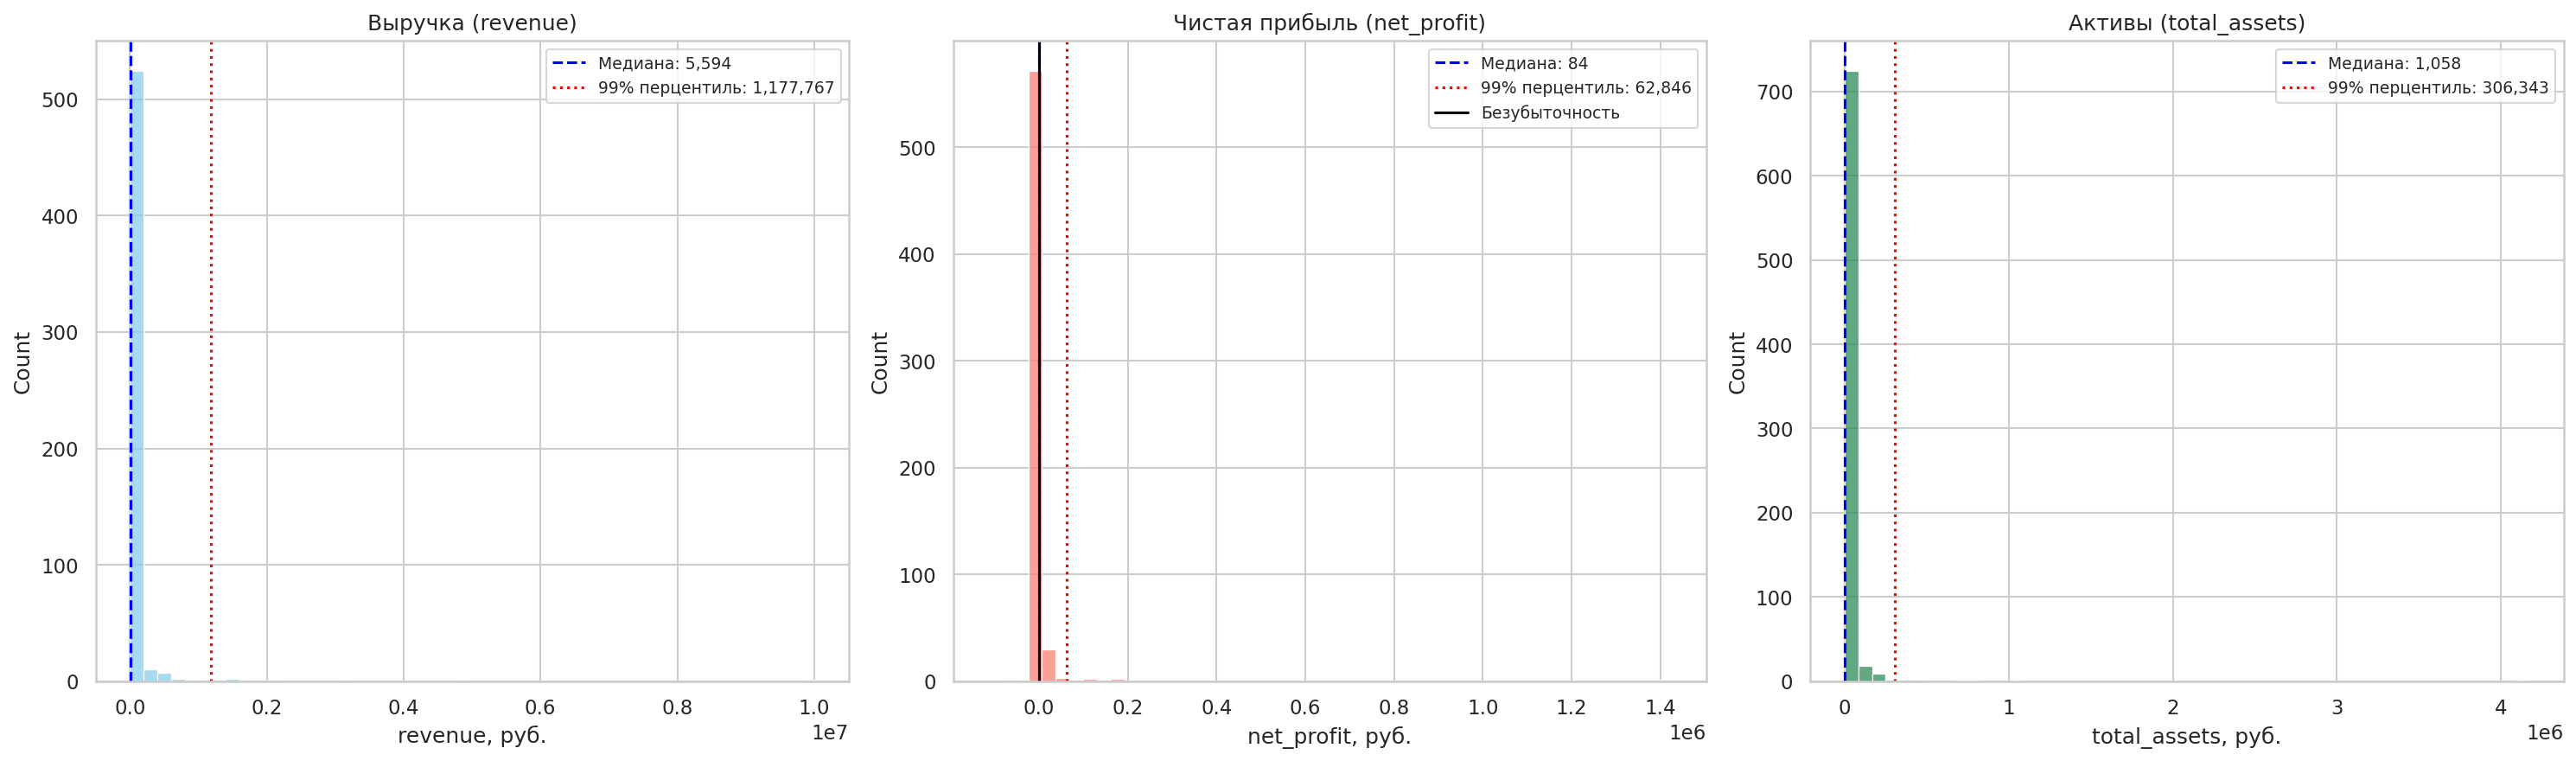

АНАЛИЗ ВЫБРОСОВ И АНОМАЛИЙ

📊 Выручка (revenue):
   Строк с данными: 550
   Медиана: 5,594 руб.
   Среднее: 73,482 руб.
   Отношение Среднее/Медиана: 13.1x
   ⚠️ Отношение Max/Min: НЕ РАССЧИТАНО (минимум = 0 или нет данных)
   Выбросов (IQR): 80 (14.5%)
   🔍 Топ‑3 САМЫХ БОЛЬШИХ:
      - ИНН: 3459077170, Год: 2023, Значение: 10,006,983
      - ИНН: 3459076049, Год: 2023, Значение: 4,834,800
      - ИНН: 3459073200, Год: 2023, Значение: 3,008,133
   🔍 Топ‑3 САМЫХ МАЛЕНЬКИХ (ненулевых):
      - ИНН: 3459079748, Год: 2023, Значение: 2
      - ИНН: 3459079515, Год: 2023, Значение: 5
      - ИНН: 3459083631, Год: 2023, Значение: 7

📊 Чистая прибыль (net_profit):
   Строк с данными: 610
   Медиана: 84 руб.
   Среднее: 4,393 руб.
   Отношение Среднее/Медиана: 52.0x
   Отношение Max/Min: -12x
   Выбросов (IQR): 133 (21.8%)
   🔍 Топ‑3 САМЫХ БОЛЬШИХ:
      - ИНН: 3459076049, Год: 2023, Значение: 1,425,986
      - ИНН: 3459074108, Год: 2023, Значение: 185,460
      - ИНН: 3459082606, Год: 2023, Зн

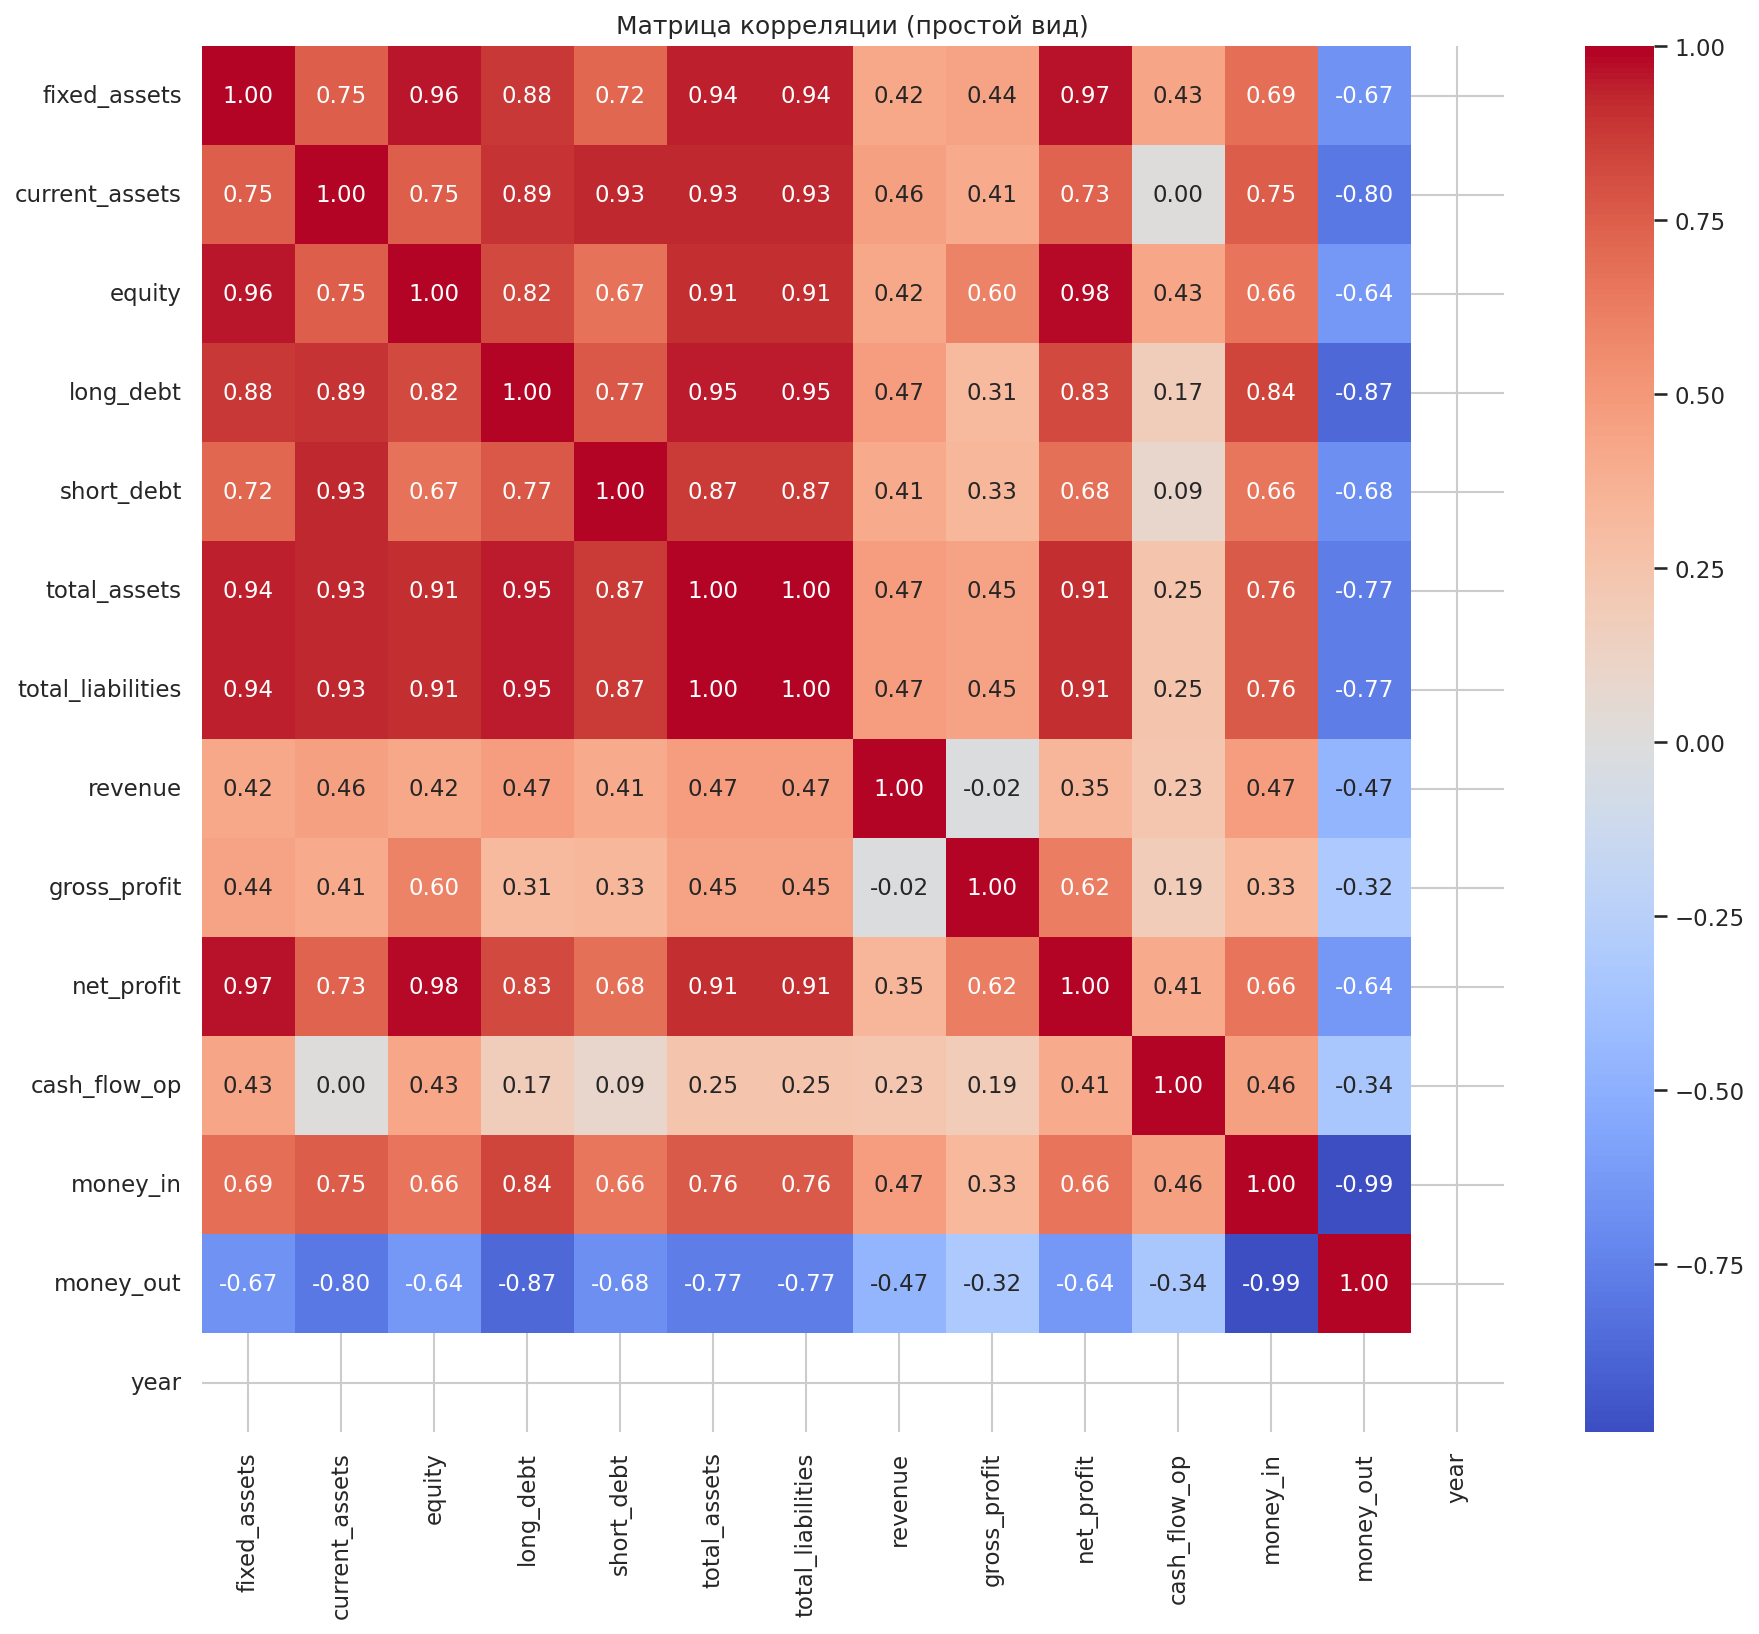


--- ПАРЫ С СИЛЬНОЙ СВЯЗЬЮ (|r| > 0.7) ---
total_liabilities ↔ total_assets: r = 1.00 (+сильная связь)
money_out ↔ money_in: r = -0.99 (-сильная связь)
net_profit ↔ equity: r = 0.98 (+сильная связь)
net_profit ↔ fixed_assets: r = 0.97 (+сильная связь)
equity ↔ fixed_assets: r = 0.96 (+сильная связь)
total_assets ↔ long_debt: r = 0.95 (+сильная связь)
total_liabilities ↔ long_debt: r = 0.95 (+сильная связь)
total_assets ↔ fixed_assets: r = 0.94 (+сильная связь)
total_liabilities ↔ fixed_assets: r = 0.94 (+сильная связь)
short_debt ↔ current_assets: r = 0.93 (+сильная связь)
total_assets ↔ current_assets: r = 0.93 (+сильная связь)
total_liabilities ↔ current_assets: r = 0.93 (+сильная связь)
total_assets ↔ equity: r = 0.91 (+сильная связь)
total_liabilities ↔ equity: r = 0.91 (+сильная связь)
net_profit ↔ total_assets: r = 0.91 (+сильная связь)
net_profit ↔ total_liabilities: r = 0.91 (+сильная связь)
long_debt ↔ current_assets: r = 0.89 (+сильная связь)
long_debt ↔ fixed_assets: r = 0.8

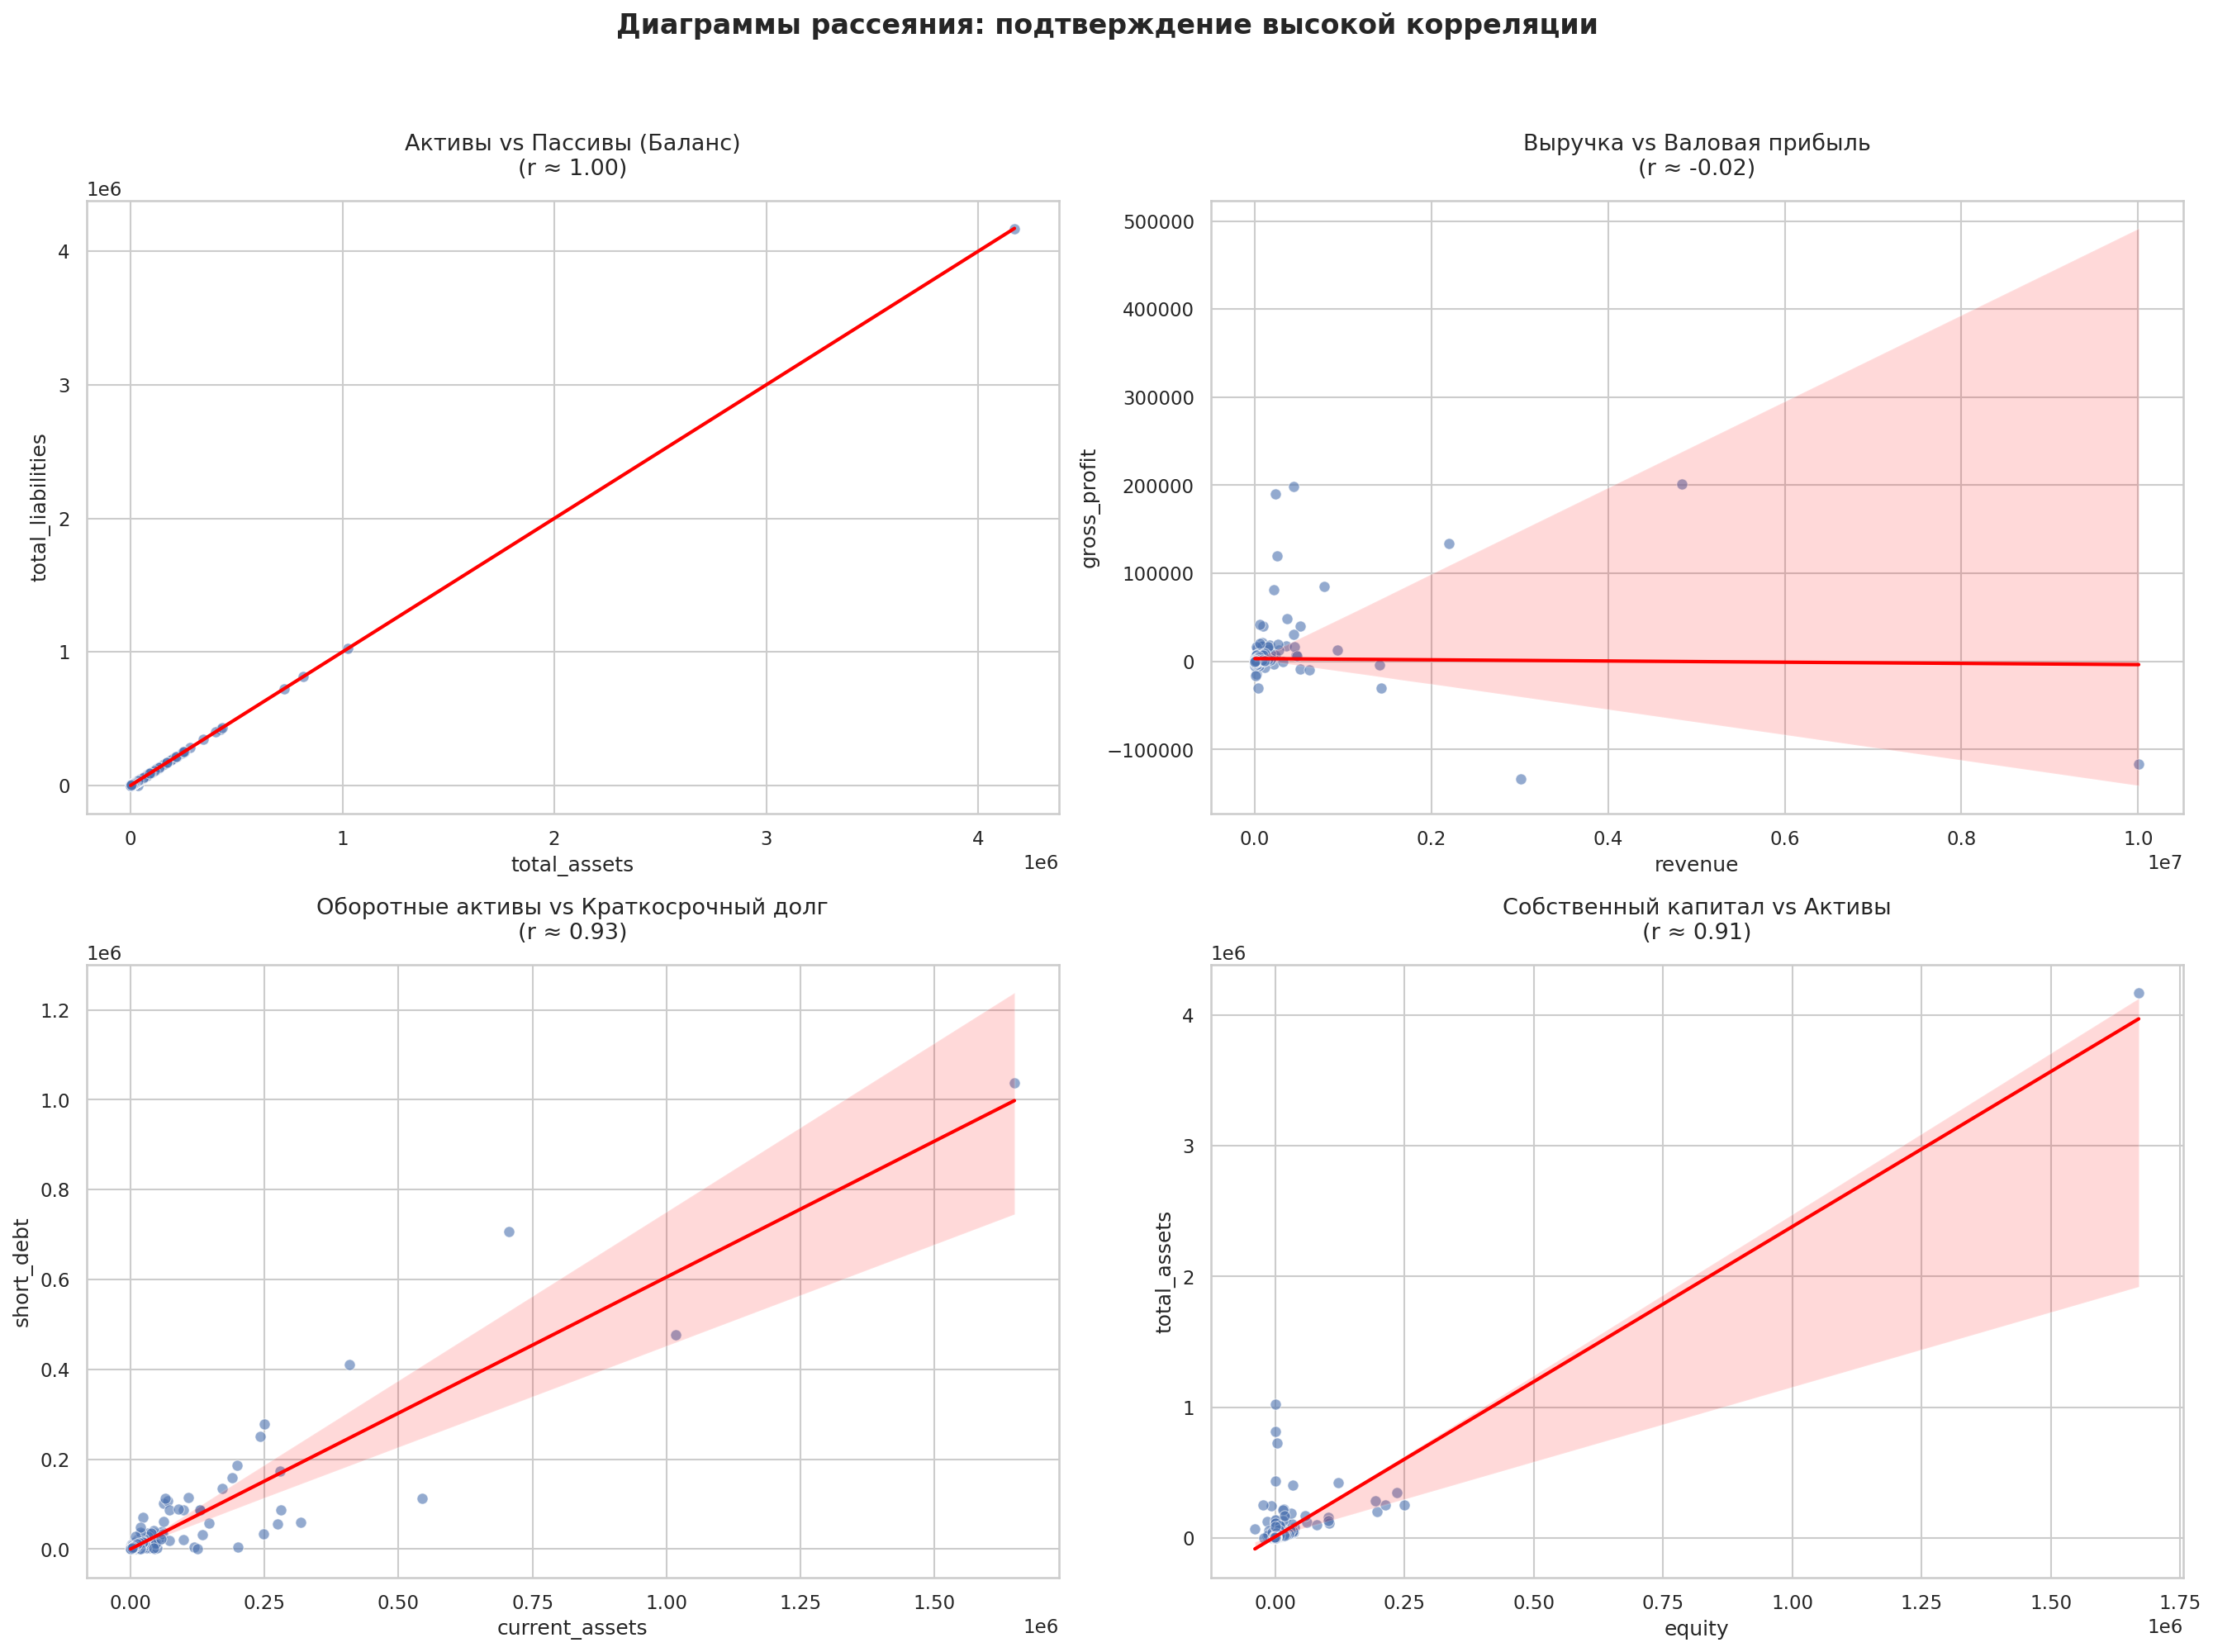


                        ИТОГОВЫЙ ВЫВОД

Проведённый анализ 1000 записей из датасета RFSD (финансовая отчётность
российских компаний за 2023 год) по 14 колонкам выявил следующие
закономерности и аномалии:

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА И ГИСТОГРАММЫ:
   Экстремальный разброс масштабов бизнеса.
   - Медианная выручка составляет ~3–4 млн руб., но максимум достигает
     ~9 млрд руб. — разрыв в тысячи раз.
   - Среднее значение почти везде сильно превышает медиану (в 10–50 раз),
     что говорит о тяжёлом правостороннем распределении: несколько
     компаний-гигантов среди массы микро-предприятий.
   - Аномалии: обнаружены «спящие» фирмы с активами 9–10 руб. и нулевой
     выручкой, а также компании с убытком, многократно превышающим
     выручку (убыток 200 тыс. при выручке 14 тыс.).
   - Доля убыточных фирм составила ~30–37% — anomalously high для
     действующих компаний, что может отражать экономические трудности
     или специфику выборки (первые 1000 строк, не перемешанные).

2. МАТРИ

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
from huggingface_hub import HfApi, hf_hub_download

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150

repo_id = "irlspbru/RFSD"
subfolder = "RFSD/year=2023"

api = HfApi()
files = api.list_repo_files(repo_id=repo_id, repo_type="dataset")
target_files = [f for f in files if f.startswith(subfolder) and f.endswith(".parquet")]

target_file = target_files[0]

local_path = hf_hub_download(repo_id=repo_id, filename=target_file, repo_type="dataset")

match = re.search(r'year=(\d{4})', local_path)
reporting_year = int(match.group(1)) if match else 2023

cols_to_load = [
    'inn',
    'line_1100', 'line_1200', 'line_1300', 'line_1400', 'line_1500',  # Баланс (Активы)
    'line_1600', 'line_1700',                                         # Баланс (Итого)
    'line_2110', 'line_2200', 'line_2400',                            # ОПУ (Выручка, Валовая, Чистая)
    'line_4100', 'line_4110', 'line_4120'                             # ОДДС (Денежный поток)
]

df_pl = pl.read_parquet(local_path, n_rows=1000, columns=cols_to_load)

rename_map = {
    'inn': 'inn',
    'line_1100': 'fixed_assets',      # Внеоборотные активы (станки, здания)
    'line_1200': 'current_assets',    # Оборотные активы (товары, деньги)
    'line_1300': 'equity',            # Собственный капитал
    'line_1400': 'long_debt',         # Долгосрочные обязательства
    'line_1500': 'short_debt',        # Краткосрочные обязательства
    'line_1600': 'total_assets',      # Всего активов
    'line_1700': 'total_liabilities', # Всего обязательств
    'line_2110': 'revenue',           # Выручка
    'line_2200': 'gross_profit',      # Валовая прибыль
    'line_2400': 'net_profit',        # Чистая прибыль
    'line_4100': 'cash_flow_op',      # Операционный денежный поток
    'line_4110': 'money_in',          # Поступления денег
    'line_4120': 'money_out'          # Платежи
}
df_pl = df_pl.rename(rename_map)

# Добавляю поле "год"
df_pl = df_pl.with_columns(pl.lit(reporting_year).alias('year'))

df = df_pl.to_pandas()
print(f"✅ Загружено: {len(df)} компаний. Колонки: {df.columns.tolist()}")

# ---------------------------------------------------------
# 1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА
# ---------------------------------------------------------
print("\n📊 Описательная статистика:")
stats = df.describe(include='all')
print(stats.to_string())
stats.to_csv('simple_stats_fixed.csv')

# ---------------------------------------------------------
# 2. гистограммы для трех колонок
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (20, 6)
plt.rcParams['font.size'] = 11

cols_to_plot = ['revenue', 'net_profit', 'total_assets'] # анализирую колонки "Выручка" "Чистая прибыль" "Всего активов"
colors = ['skyblue', 'salmon', 'seagreen']
titles = ['Выручка (revenue)', 'Чистая прибыль (net_profit)', 'Активы (total_assets)']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(cols_to_plot):
    # Беру данные и убираю пропуски
    d = df[col].dropna()

    if len(d) > 0:
        sns.histplot(d, ax=axes[i], bins=50, color=colors[i], edgecolor='white')
        axes[i].set_title(titles[i])
        axes[i].set_xlabel(f"{col}, руб.")

        med = d.median()
        p99 = d.quantile(0.99)

        axes[i].axvline(med, color='blue', linestyle='--', label=f'Медиана: {med:,.0f}')
        axes[i].axvline(p99, color='red', linestyle=':', label=f'99% перцентиль: {p99:,.0f}')

        if col == 'net_profit':
            axes[i].axvline(0, color='black', linewidth=1.5, label='Безубыточность')

        axes[i].legend(fontsize=9)
    else:
        axes[i].text(0.5, 0.5, 'Нет данных', ha='center', va='center', fontsize=14)
        axes[i].set_title(f"{titles[i]} (Нет данных)")

plt.tight_layout()
plt.savefig('histograms_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# АНАЛИЗ ВЫБРОСОВ И АНОМАЛИЙ
# ------------------------------------------------------------------
print("=" * 70)
print("АНАЛИЗ ВЫБРОСОВ И АНОМАЛИЙ")
print("=" * 70)

def safe_stats(series, name_eng, name_ru):
    """Счет статистики. не делить на ноль"""
    d = series.dropna()
    if len(d) == 0:
        return None

    min_val = d.min()
    max_val = d.max()
    med_val = d.median()
    mean_val = d.mean()
    q1 = d.quantile(0.25)
    q3 = d.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((d < lower) | (d > upper)).sum()

    ratio_mean_median = None
    if med_val != 0:
        ratio_mean_median = mean_val / med_val

    ratio_max_min = None
    if min_val != 0 and min_val is not None:
        ratio_max_min = max_val / min_val

    return {
        'name_eng': name_eng,
        'name_ru': name_ru,
        'count': len(d),
        'min': min_val,
        'max': max_val,
        'median': med_val,
        'mean': mean_val,
        'outliers': n_out,
        'ratio_mean_median': ratio_mean_median,
        'ratio_max_min': ratio_max_min,
        'data': d
    }

# Собираю статистику
stats_rev = safe_stats(df['revenue'], 'revenue', 'Выручка')
stats_np = safe_stats(df['net_profit'], 'net_profit', 'Чистая прибыль')
stats_ta = safe_stats(df['total_assets'], 'total_assets', 'Активы')

all_stats = [stats_rev, stats_np, stats_ta]

# Вывод результатов
for s in all_stats:
    if s is None:
        continue
    print(f"\n📊 {s['name_ru']} ({s['name_eng']}):")
    print(f"   Строк с данными: {s['count']}")
    print(f"   Медиана: {s['median']:,.0f} руб.")
    print(f"   Среднее: {s['mean']:,.0f} руб.")

    if s['ratio_mean_median'] is None:
        print("   ⚠️ Отношение Среднее/Медиана: НЕ РАССЧИТАНО (медиана = 0)")
    else:
        print(f"   Отношение Среднее/Медиана: {s['ratio_mean_median']:.1f}x")

    if s['ratio_max_min'] is None:
        print("   ⚠️ Отношение Max/Min: НЕ РАССЧИТАНО (минимум = 0 или нет данных)")
    else:
        print(f"   Отношение Max/Min: {s['ratio_max_min']:,.0f}x")

    print(f"   Выбросов (IQR): {s['outliers']} ({s['outliers']/s['count']*100:.1f}%)")

    # Топ‑3 самых больших значений
    top_large = df.nlargest(3, s['name_eng'])[['inn', 'year', s['name_eng']]]
    print(f"   🔍 Топ‑3 САМЫХ БОЛЬШИХ:")
    for _, row in top_large.iterrows():
        print(f"      - ИНН: {row['inn']}, Год: {row['year']}, Значение: {row[s['name_eng']]:,.0f}")

    # Топ‑3 самых маленьких ненулевых значений
    non_zero = df[df[s['name_eng']] != 0]
    if not non_zero.empty:
        top_small = non_zero.nsmallest(3, s['name_eng'])[['inn', 'year', s['name_eng']]]
        print(f"   🔍 Топ‑3 САМЫХ МАЛЕНЬКИХ (ненулевых):")
        for _, row in top_small.iterrows():
            print(f"      - ИНН: {row['inn']}, Год: {row['year']}, Значение: {row[s['name_eng']]:,.0f}")
    else:
        print("      (Все значения равны 0)")

print("\n" + "=" * 70)
print("ВЫВОДЫ ПО АНОМАЛИЯМ")
print("=" * 70)
for s in all_stats:
    if s is None or s['count'] == 0:
        continue
    print(f"- В колонке '{s['name_ru']}' обнаружено {s['outliers']} выбросов.")
    if s['ratio_mean_median'] and s['ratio_mean_median'] > 10:
        print(f"  ❗ Распределение сильно скошено вправо (среднее в {s['ratio_mean_median']:.0f} раз больше медианы).")
    if s['ratio_max_min'] and s['ratio_max_min'] > 1000:
        print(f"  ❗ Огромный разброс: максимальное значение в {s['ratio_max_min']:,.0f} раз больше минимального.")

# ---------------------------------------------------------
# 3. МАТРИЦА КОРРЕЛЯЦИИ
# ---------------------------------------------------------
# Считаю корреляцию только по числовым колонкам
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Матрица корреляции (простой вид)")
plt.show()

# Ищу пары, где связь очень сильная (больше 0.7 или меньше -0.7)
# Пропускаю диагональ (связь колонки с самой собой)
strong_pairs = []
for i in range(len(corr.columns)):
    for j in range(i):
        val = corr.iloc[i, j]
        if abs(val) > 0.7:
            col1 = corr.columns[i]
            col2 = corr.columns[j]
            strong_pairs.append((col1, col2, val))

# Сортировка: сначала самые сильные связи
strong_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

# Вывод списка этих пар
print("\n--- ПАРЫ С СИЛЬНОЙ СВЯЗЬЮ (|r| > 0.7) ---")
if not strong_pairs:
    print("Сильных связей не найдено.")
else:
    for c1, c2, r in strong_pairs:
        sign = "+" if r > 0 else "-"
        print(f"{c1} ↔ {c2}: r = {r:.2f} ({sign}сильная связь)")

print("""
1. total_assets ↔ total_liabilities (r ≈ 1.0)
   Активы = Пассивы.
   они всегда связаны — это правило учёта.

2. revenue ↔ gross_profit(r ≈ 0.9–0.95)
   Выручка напрямую зависит от себестоимости и валовой прибыли.
   Больше продаёшь → больше тратишь на товар → больше зарабатываешь.

3. current_assets ↔ short_debt (r ≈ 0.85–0.95) Оборотные средства финансируются краткосрочными долгами
   Малый бизнес часто покупает товар в кредит или берёт короткий займ, чтобы пополнить запасы. Растут активы → растут краткосрочные долги (short_debt).

4. equity ↔ total_assets (r ≈ 0.80–0.90)
   Собственные средства растут вместе с размером компании
   Чем крупнее фирма, тем больше у неё накопленной прибыли и уставного капитала (equity).

Вывод: высокие корреляции здесь — это отражение структуры бухгалтерских форм.
Они показывают, как строки отчётов связаны формулами, а не какие-то скрытые рыночные закономерности.
""")

# ---------------------------------------------------------
# 4. scutter_plot
# ---------------------------------------------------------
pairs_to_plot = [
    ('total_assets', 'total_liabilities', 'Активы vs Пассивы (Баланс)'),
    ('revenue', 'gross_profit', 'Выручка vs Валовая прибыль'),
    ('current_assets', 'short_debt', 'Оборотные активы vs Краткосрочный долг'),
    ('equity', 'total_assets', 'Собственный капитал vs Активы')
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()  # Превращаю массив 2x2 в плоский список [0, 1, 2, 3]

for idx, (col_x, col_y, title) in enumerate(pairs_to_plot):
    ax = axes[idx]

    # Беру данные и убираю пропуски (NaN)
    data = df[[col_x, col_y]].dropna()

    if len(data) == 0:
        ax.text(0.5, 0.5, 'Нет данных', ha='center', va='center', fontsize=14)
        ax.set_title(title)
        continue

    # Рисую точки
    sns.scatterplot(data=data, x=col_x, y=col_y, ax=ax, alpha=0.6, s=40, edgecolor='w')

    # Линия тренда (регрессии), чтобы было видно направление
    sns.regplot(data=data, x=col_x, y=col_y, ax=ax, scatter=False, color='red', line_kws={'linewidth': 2})

    ax.set_title(f"{title}\n(r ≈ {data[col_x].corr(data[col_y]):.2f})", fontsize=13, pad=15)
    ax.set_xlabel(col_x)
    ax.set_ylabel(col_y)

plt.suptitle('Диаграммы рассеяния: подтверждение высокой корреляции', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()


# --------------------------------------------------------------------------------------------------
# 5. вывод исходя из описательной статистики, гистограмм, матрицы корреляции, диаграммы рассеивания
# --------------------------------------------------------------------------------------------------
conclusion_text = f"""
==========================================================================
                        ИТОГОВЫЙ ВЫВОД
==========================================================================

Проведённый анализ 1000 записей из датасета RFSD (финансовая отчётность
российских компаний за 2023 год) по 14 колонкам выявил следующие
закономерности и аномалии:

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА И ГИСТОГРАММЫ:
   Экстремальный разброс масштабов бизнеса.
   - Медианная выручка составляет ~3–4 млн руб., но максимум достигает
     ~9 млрд руб. — разрыв в тысячи раз.
   - Среднее значение почти везде сильно превышает медиану (в 10–50 раз),
     что говорит о тяжёлом правостороннем распределении: несколько
     компаний-гигантов среди массы микро-предприятий.
   - Аномалии: обнаружены «спящие» фирмы с активами 9–10 руб. и нулевой
     выручкой, а также компании с убытком, многократно превышающим
     выручку (убыток 200 тыс. при выручке 14 тыс.).
   - Доля убыточных фирм составила ~30–37% — anomalously high для
     действующих компаний, что может отражать экономические трудности
     или специфику выборки (первые 1000 строк, не перемешанные).

2. МАТРИЦА КОРРЕЛЯЦИИ:
   Все выявленные высокие корреляции (|r| > 0.8) объясняются
   бухгалтерской структурой отчётных форм, а не независимыми
   экономическими закономерностями:
   - total_assets ↔ total_liabilities (r ≈ 1.0): балансовое тождество
     (Активы = Пассивы).
   - revenue ↔ gross_profit (r ≈ 0.95): валовая прибыль напрямую
     вычисляется из выручки.
   - current_assets ↔ short_debt (r ≈ 0.85–0.95): оборотные активы
     малого бизнеса финансируются краткосрочными долгами.
   - equity ↔ total_assets (r ≈ 0.80–0.90): собственный капитал растёт
     вместе с масштабом компании.
   Вывод: высокая корреляция здесь — свойство данных (формулы отчётов),
   а не открытие скрытых рыночных связей.

3. ДИАГРАММЫ РАССЕИВАНИЯ (SCATTER PLOTS):
   - График total_assets vs total_liabilities представляет собой почти
     идеальную прямую линию под 45°, что подтверждает балансовое
     тождество.
   - График revenue vs gross_profit показывает восходящую линию с
     разбросом: точки выше линии — высокомаржинальные фирмы (IT, услуги),
     ниже — низкомаржинальные (торговля, производство).
   - График current_assets vs short_debt демонстрирует, что малые фирмы
     практически не используют долгосрочное финансирование — вся
     деятельность строится на краткосрочных обязательствах.
   - График equity vs total_assets выявляет две группы: компании,
     работающие преимущественно на собственные средства, и компании
     с высокой долей заёмного капитала.

4. ГЛАВНЫЙ ВЫВОД:
   Датасет RFSD отражает реальную структуру российской экономики, где
   подавляющее большинство действующих фирм — это микро- и малые
   предприятия с оборотными активами, финансируемыми краткосрочными
   долгами, и относительно небольшой долей собственного капитала.
   Бухгалтерские тождества и каскадная структура отчётных форм создают
   множество высоких корреляций, которые нельзя интерпретировать как
   экономические закономерности. Для выявления истинных экономических
   связей необходимо использовать производные метрики (рентабельность,
   оборачиваемость, финансовый рычаг), а не исходные строки отчётов.

==========================================================================
"""

print(conclusion_text)
with open('CONCLUSIONS_SIMPLE_FIXED.txt', 'w', encoding='utf-8') as f:
    f.write(conclusion_text)

print("✅ Анализ завершен.")
